# Business Understanding :   

Businesses have customers with different levels of income, spending behavior, and purchasing frequency. Treating all customers the same can lead to ineffective marketing and customer engagement strategies.   

The objective of this project is to **segment customers into meaningful groups** based on their **age, annual income, spending score, and purchase frequency** using K-Means clustering.   

These customer segments can help businesses:   

* Identify **high-value and highly engaged customers**   
* Develop **targeted marketing campaigns**   
* Identify customers with **low spending or low purchase frequency**   
* Create personalized offers and promotions  
* Improve customer retention and engagement  
* Support data-driven marketing and business decisions   

Since there is no predefined target variable, this is an **unsupervised learning problem**, where the model discovers natural customer groups from the available data.  


#### Import Important Libraries : 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

#### Load the Dataset :

In [2]:
df = pd.read_excel("customer_segmentation.xlsx")

### Exploratry Data Analysis (EDA) :

In [3]:
# Head of the Dataset
df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency
0,10001,41,69895,46,26
1,10002,34,82597,45,17
2,10003,43,47855,15,15
3,10004,53,42529,48,10
4,10005,33,34868,71,14


In [4]:
# Tail of the Dataset 
df.tail()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency
2495,12496,45,53880,44,23
2496,12497,33,74153,44,11
2497,12498,33,180000,100,18
2498,12499,45,77224,1,15
2499,12500,40,38519,51,9


In [5]:
# Shape of the Dataset 
df.shape

(2500, 5)

In [6]:
# Columns of the Dataset
df.columns

Index(['CustomerID', 'Age', 'AnnualIncome', 'SpendingScore',
       'PurchaseFrequency'],
      dtype='object')

In [7]:
# General Information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         2500 non-null   int64
 1   Age                2500 non-null   int64
 2   AnnualIncome       2500 non-null   int64
 3   SpendingScore      2500 non-null   int64
 4   PurchaseFrequency  2500 non-null   int64
dtypes: int64(5)
memory usage: 97.8 KB


In [8]:
# Statistical Summary
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000
mean,11250.50000,36.555600,59479.233600,54.198000,17.068800
std,721.83216,10.406028,25769.469817,21.893984,4.066778
min,10001.00000,18.000000,15000.000000,1.000000,5.000000
25%,10625.75000,29.000000,40827.500000,39.000000,14.000000
50%,11250.50000,36.000000,54825.500000,54.000000,17.000000
75%,11875.25000,43.000000,72193.250000,70.000000,20.000000
max,12500.00000,70.000000,180000.000000,100.000000,35.000000


In [9]:
# To check Missing Values 
df.isnull().sum()

CustomerID           0
Age                  0
AnnualIncome         0
SpendingScore        0
PurchaseFrequency    0
dtype: int64

In [10]:
# To check Duplicate Values
df.duplicated().sum()

np.int64(0)

In [11]:
# Check duplicate CustomerID
df['CustomerID'].duplicated().sum()

np.int64(0)

In [12]:
# DataTypes of the columns

df.dtypes

CustomerID           int64
Age                  int64
AnnualIncome         int64
SpendingScore        int64
PurchaseFrequency    int64
dtype: object

In [13]:
# Uniqe Entries 
df.nunique()

CustomerID           2500
Age                    50
AnnualIncome         2458
SpendingScore         100
PurchaseFrequency      29
dtype: int64

### **Identify Features for clustering**  
**Customer_id** - No need of this column because of this is identifier column.  
**Age** - Yes this is usefull because of this describes customer's characters.  
**annualIncome**  - Yes this is also useful column because of this describes customer's financial behaviour.   
**Purchase Frequency** -  Yes ! It describe Spending behaviour 


In [14]:
# Drop Unwanted Columns:  
df.drop(columns = 'CustomerID', inplace = True)

In [15]:
# Verify 
df.head()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency
0,41,69895,46,26
1,34,82597,45,17
2,43,47855,15,15
3,53,42529,48,10
4,33,34868,71,14


## Visualization :   

### Univariate Analysis :

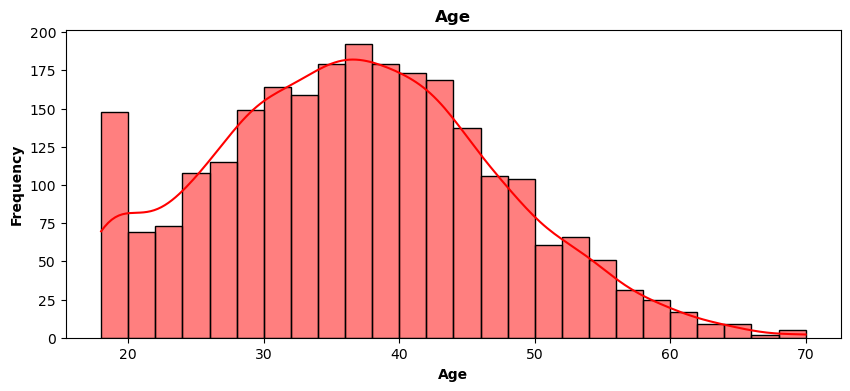

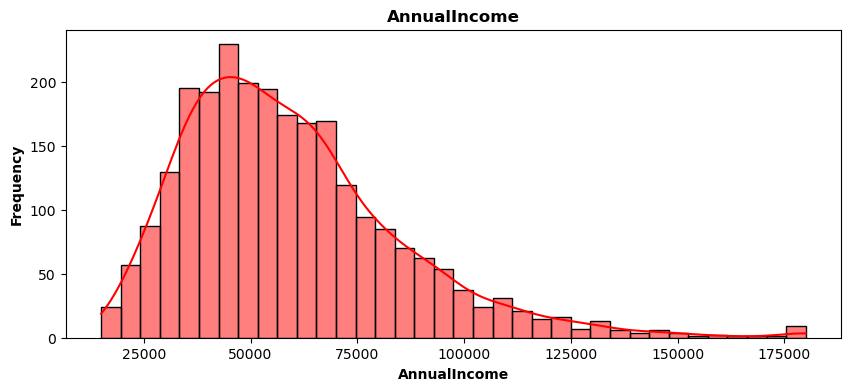

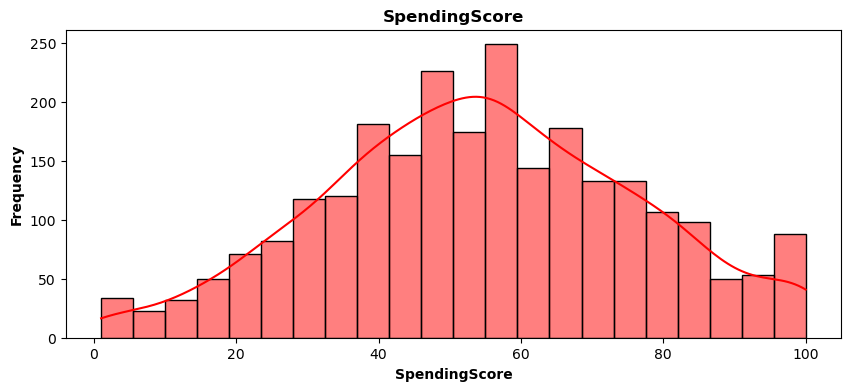

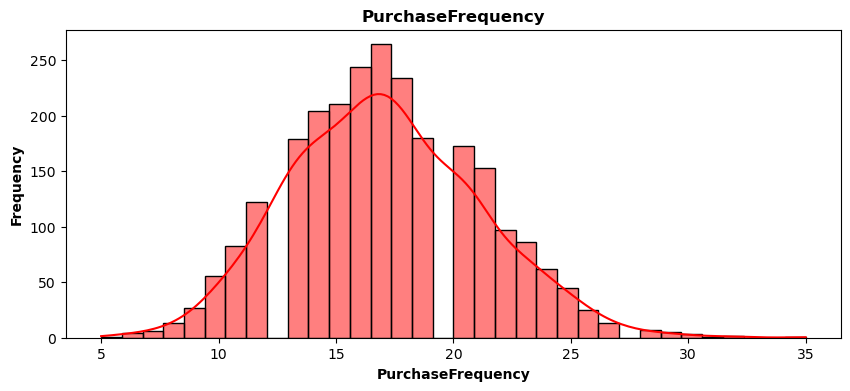

In [16]:
# HISTPLOT
for col in df.select_dtypes(include = ['float','int']).columns:
    plt.figure(figsize = (10,4))
    sns.histplot(df[col],kde = True, color = 'red')
    plt.title(col,  fontweight = 'bold')
    plt.xlabel(col, fontweight = 'bold')
    plt.ylabel("Frequency", fontweight = 'bold')
    plt.show()


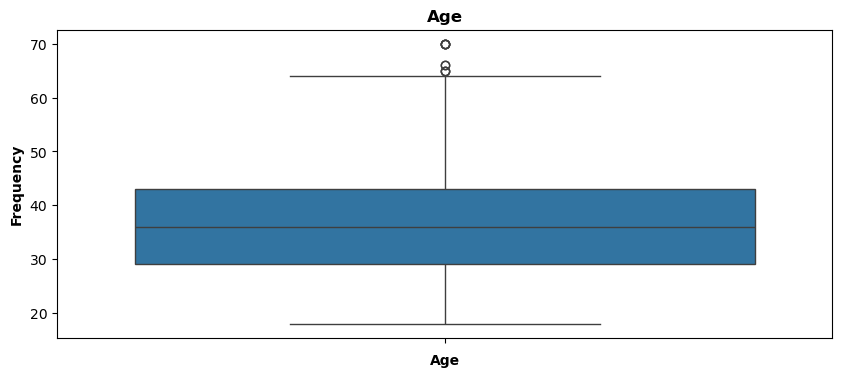

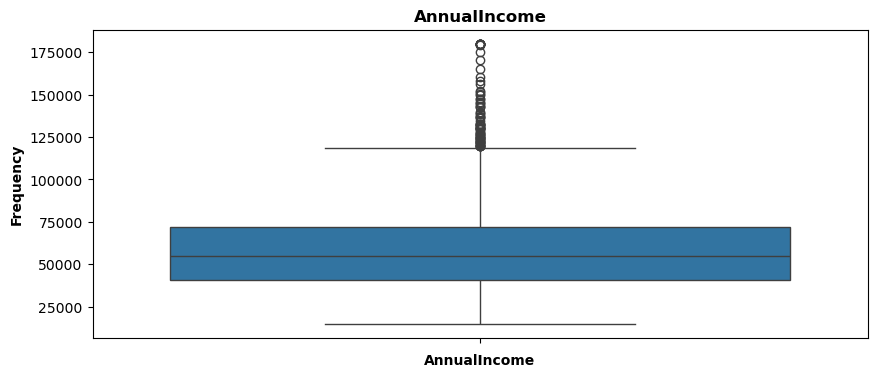

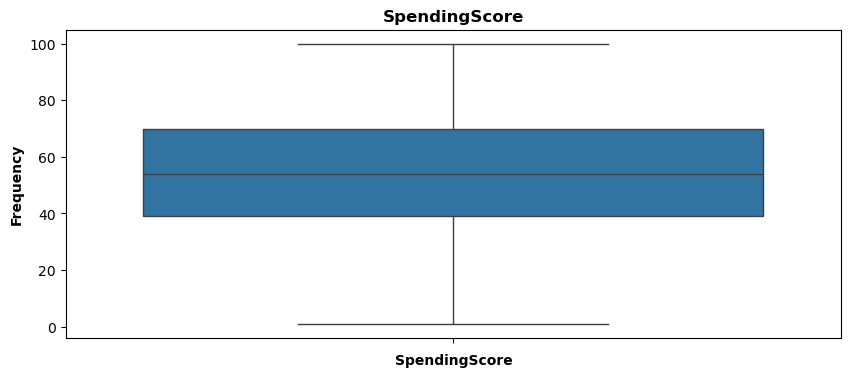

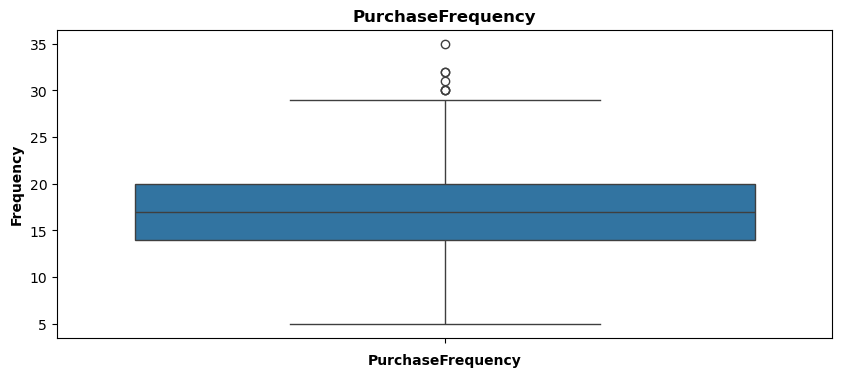

In [17]:
# Box Plot 
for col in df.select_dtypes(include = ['int','float']).columns:
    plt.figure(figsize = (10, 4))
    sns.boxplot(df[col])
    plt.title(col,  fontweight = 'bold')
    plt.xlabel(col, fontweight = 'bold')
    plt.ylabel("Frequency", fontweight = 'bold')
    plt.show()

### Multivarite Analysis: 

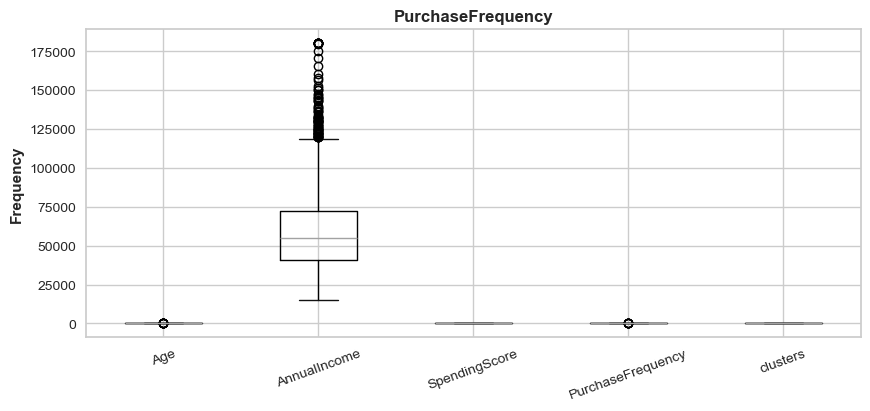

In [42]:
# BOXPLOT
plt.figure(figsize=(10,4))

df.boxplot()

plt.title("Boxplot of Customer Features")
plt.xticks(rotation=20)
plt.title(col,  fontweight = 'bold')
plt.ylabel("Frequency", fontweight = 'bold')
plt.show()
plt.show()

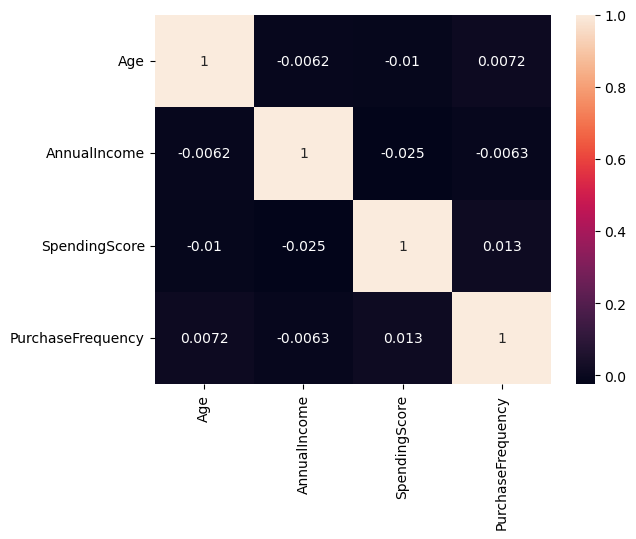

In [19]:
# HeatMap
corr = df.select_dtypes(include = ['int','float']).corr()
sns.heatmap(corr, annot= True)
plt.show()


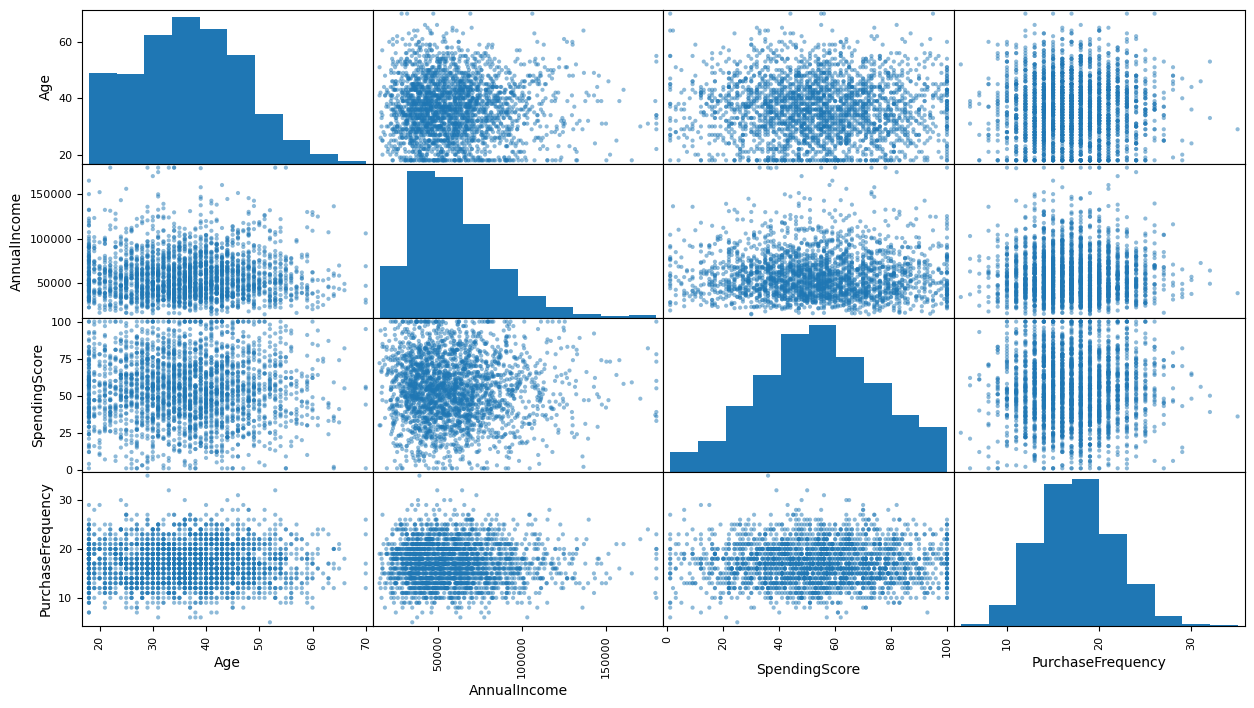

In [20]:
# SCATTER PLOT 

pd.plotting.scatter_matrix(
    df,
    figsize=(15,8)
)

plt.show()

## Clustering : 

#### Make a backup dataset :

In [21]:
df1 = df.copy()

#### Scaling :

In [22]:
# Standard Scaler 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

for i in df1:
    df1[i] = scaler.fit_transform(df1[[i]])

In [23]:
df1

,Age,AnnualIncome,SpendingScore,PurchaseFrequency
0,0.427184,0.404271,-0.374516,2.196576
1,-0.245638,0.897279,-0.420199,-0.016921
2,0.619419,-0.451176,-1.790713,-0.508809
3,1.580592,-0.657896,-0.283148,-1.738530
4,-0.341755,-0.955245,0.767579,-0.754753
...,...,...,...,...
2495,0.811654,-0.217325,-0.465883,1.458744
2496,-0.341755,0.569538,-0.465883,-1.492586
2497,-0.341755,4.677818,2.092409,0.229023
2498,0.811654,0.688734,-2.430286,-0.508809


In [24]:
df1.std()

Age                  1.0002
AnnualIncome         1.0002
SpendingScore        1.0002
PurchaseFrequency    1.0002
dtype: float64

#### Find the best K :

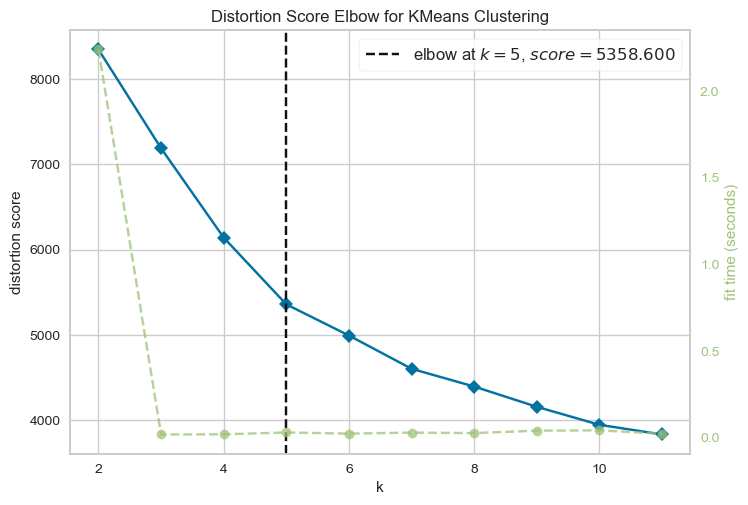

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [25]:
# Find best k 
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

visualizer = KElbowVisualizer(
    KMeans(random_state = 42),
    k = (2,12),
    metric = 'distortion',
    force_model = True
)


# Fit it 
visualizer.fit(df1)

visualizer.show()


In [26]:
print(f"The Best K : {visualizer.elbow_value_}")

The Best K : 5


#### Validate K with Silhouette Score :

In [27]:
# Validate K with Silhouette Score
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in range(2, 13):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df1)

    score = silhouette_score(df1, labels)

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.1718
K = 3, Silhouette Score = 0.1759
K = 4, Silhouette Score = 0.1808
K = 5, Silhouette Score = 0.1848
K = 6, Silhouette Score = 0.1793
K = 7, Silhouette Score = 0.1811
K = 8, Silhouette Score = 0.1722
K = 9, Silhouette Score = 0.1722
K = 10, Silhouette Score = 0.1717
K = 11, Silhouette Score = 0.1690
K = 12, Silhouette Score = 0.1703


####  Plot silhuette score :

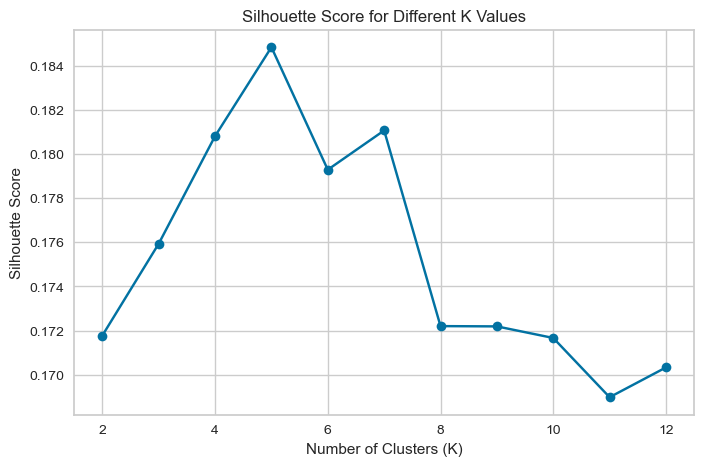

In [28]:
# Plot silhuette score

plt.figure(figsize=(8,5))

plt.plot(
    range(2, 13),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

### Train the Final K-Means Model

In [29]:
# Train the Final K-Means Model

best_k = 4
final_kmeans = KMeans(
    n_clusters = best_k,
    random_state = 42,
    n_init = 10
)

#### Fit and Predict :


In [30]:
# fit and predict

clusters = final_kmeans.fit_predict(df1)

#### ADD cluster label on original dataset  :

In [31]:
# ADD cluster label on original dataset 

df['clusters'] = clusters

In [32]:
df.head()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,clusters
0,41,69895,46,26,3
1,34,82597,45,17,2
2,43,47855,15,15,1
3,53,42529,48,10,1
4,33,34868,71,14,0


In [33]:

df["clusters"].value_counts().sort_index()

clusters
0    773
1    695
2    381
3    651
Name: count, dtype: int64

In [34]:

features = df.select_dtypes(include = ['int','float']).columns

#### Create a  DataFrame to get insights : 

In [35]:
clusters_summary = df.groupby("clusters")[features].mean()

clusters_summary

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,clusters
clusters,,,,,
0,33.009056,49379.111255,69.372574,14.595084,0.0
1,42.307914,53327.457554,34.641727,15.543885,1.0
2,35.133858,104063.427822,55.417323,16.677165,2.0
3,35.457757,51946.669739,56.344086,21.863287,3.0


# Insights : 

#### **🟢 Cluster 0 — High-Spending Customers**  
Age              → 33 years  
Annual Income    → ₹49,379  
Spending Score   → 69.37  
Purchase Frequency → 14.60  

These customers have:  

Relatively young age  
Moderate income  
Highest Spending Score  
Moderate purchase frequency  
Customer segment:  

High-Spending Customers   

They don't have the highest income, but they spend heavily relative to other groups.

### **Business strategy:**

You could target them with:

Premium products
Personalized recommendations
Loyalty rewards
Cross-selling
Special offers  

#### **🟡 Cluster 1 — Low-Spending / Older Customers**    
Age              → 42.3 years  
Annual Income    → ₹53,327   
Spending Score   → 34.64   
Purchase Frequency → 15.54   

These customers are:  

The oldest cluster  
Moderate income  
Lowest Spending Score  
Moderate purchase frequency  

Customer segment:  
Low-Spending Customers  
They purchase reasonably often but don't spend heavily.  

### **Business strategy:**    
Use:  
Discounts    
Value-for-money products    
Personalized offers    
Re-engagement campaigns  
The goal would be to increase their spending.  

**🔵 Cluster 2 — High-Income Customers**  
Age              → 35.1 years    
Annual Income    → ₹104,063   
Spending Score   → 55.42   
Purchase Frequency → 16.68   

This is the most financially valuable-looking group because:

Age is relatively young
Annual income is extremely high
Spending score is moderate-high
Purchase frequency is relatively high
Customer segment:

High-Income Customers

They have substantially higher income than the other clusters.

### Business strategy:
Target them with:
Premium products
Luxury products
High-value memberships
Exclusive offers
Premium customer service  

#### **🔴 Cluster 3 — Frequent Buyers**   
Age              → 35.5 years  
Annual Income    → ₹51,947   
Spending Score   → 56.34   
Purchase Frequency → 21.86    

This is the most interesting cluster from a customer loyalty perspective.    

They have:   

Moderate income    
Moderate-high Spending Score  
Highest Purchase Frequency  
Relatively young age

Customer segment:   
Frequent Buyers / Loyal Customers    
They don't have the highest income, but they purchase much more frequently than the other clusters. 

### Business strategy:
Use:  
Loyalty programs  
Memberships    
Repeat-purchase rewards   
Subscription offers    
Referral programs     

## ⭐ Overall Business Interpretation

Your four clusters can be summarized as:  
Cluster 0 → High Spenders  
Cluster 1 → Low Spenders   
Cluster 2 → High-Income Customers  
Cluster 3 → Frequent Buyers   

## Customer Segmentation Visualization :

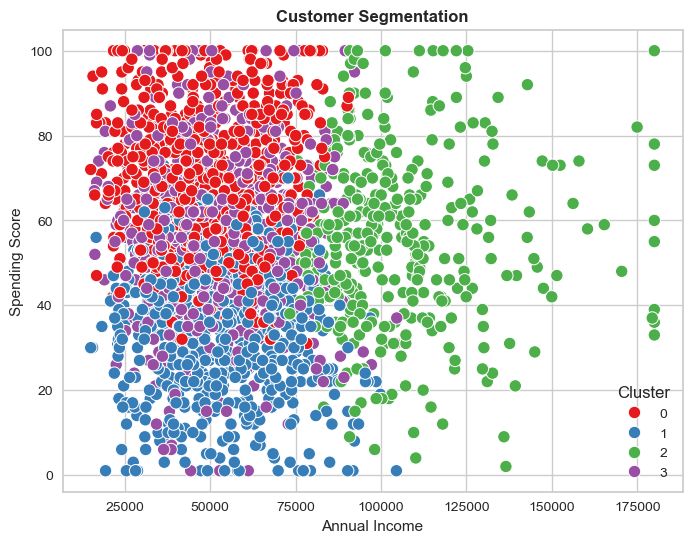

In [36]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='AnnualIncome',
    y='SpendingScore',
    hue='clusters',
    palette='Set1',
    s=80
)

plt.title('Customer Segmentation', fontweight='bold')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.show()

#### 3-D Visualization of Customer Clusters Based on Customer Characteristics

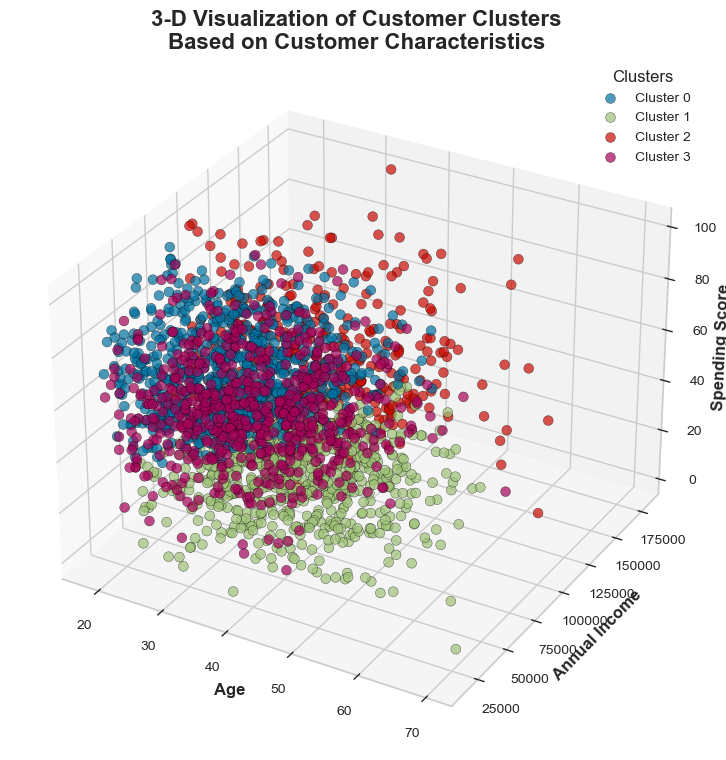

In [37]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))

ax = fig.add_subplot(111, projection='3d')

# Plot each cluster
for cluster in sorted(df['clusters'].unique()):

    cluster_data = df[df['clusters'] == cluster]

    ax.scatter(
        cluster_data['Age'],
        cluster_data['AnnualIncome'],
        cluster_data['SpendingScore'],
        s=50,
        alpha=0.7,
        edgecolor='black',
        label=f'Cluster {cluster}'
    )

# Axis labels
ax.set_xlabel('Age', fontsize=12, fontweight='bold')
ax.set_ylabel('Annual Income', fontsize=12, fontweight='bold')
ax.set_zlabel('Spending Score', fontsize=12, fontweight='bold')

# Title
ax.set_title(
    "3-D Visualization of Customer Clusters\nBased on Customer Characteristics",
    fontsize=16,
    fontweight='bold'
)

# Legend
ax.legend(title='Clusters')

plt.show()

#### K-Means Customer Segmentation :

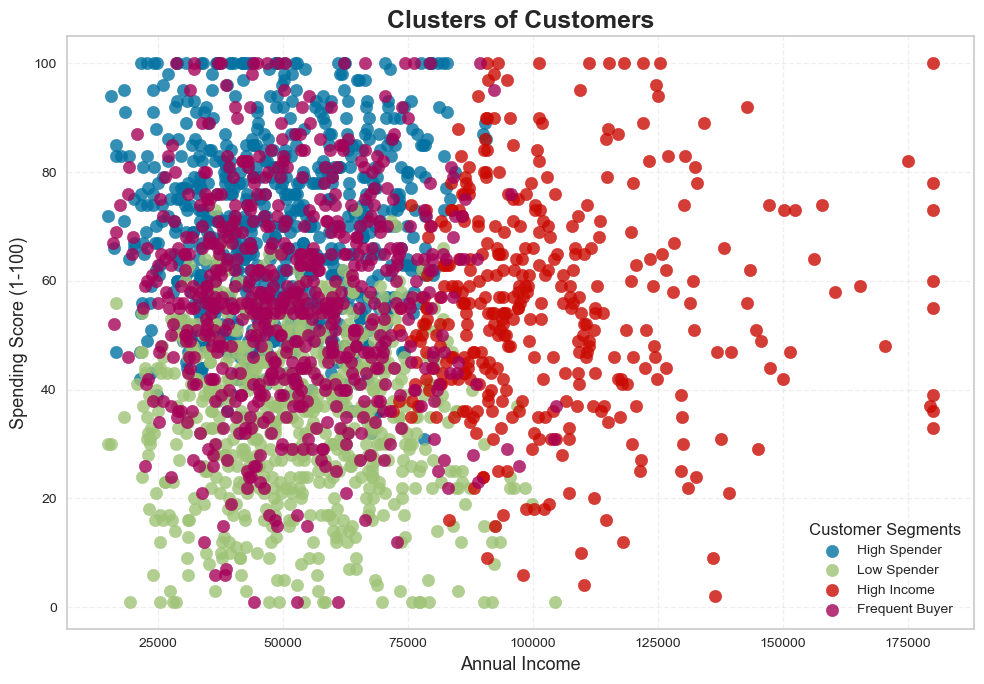

In [38]:
import matplotlib.pyplot as plt

# Cluster names
cluster_names = {
    0: "High Spender",
    1: "Low Spender",
    2: "High Income",
    3: "Frequent Buyer"
}

# Create figure
plt.figure(figsize=(10, 7))

# Plot each cluster
for cluster in sorted(df["clusters"].unique()):

    data = df[df["clusters"] == cluster]

    plt.scatter(
        data["AnnualIncome"],
        data["SpendingScore"],
        s=80,
        alpha=0.8,
        label=cluster_names[cluster]
    )

# Title
plt.title(
    "Clusters of Customers",
    fontsize=18,
    fontweight="bold"
)

# Axis labels
plt.xlabel(
    "Annual Income",
    fontsize=13
)

plt.ylabel(
    "Spending Score (1-100)",
    fontsize=13
)

# Grid
plt.grid(
    linestyle="--",
    alpha=0.3
)

# Legend
plt.legend(
    title="Customer Segments",
    loc="best"
)

plt.tight_layout()

plt.show()

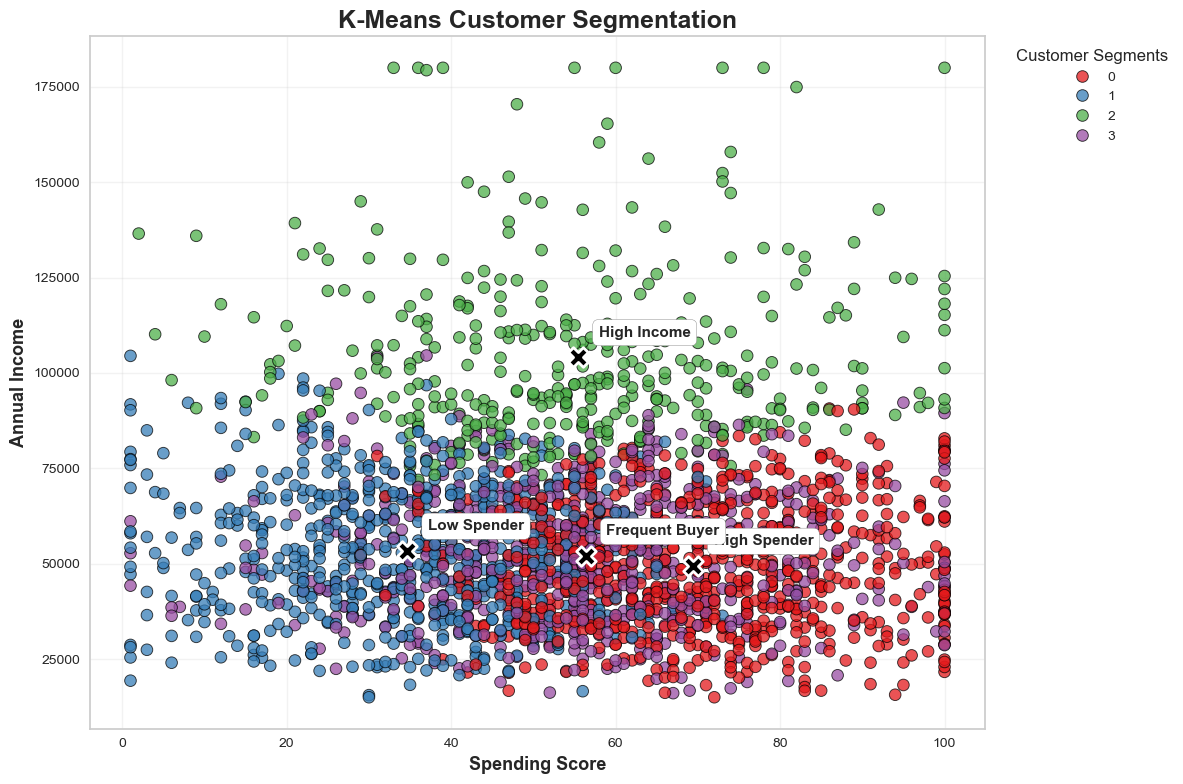

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cluster names
cluster_names = {
    0: "High Spender",
    1: "Low Spender",
    2: "High Income",
    3: "Frequent Buyer"
}

# Create figure
plt.figure(figsize=(12, 8))

# Scatter plot
sns.scatterplot(
    data=df,
    x="SpendingScore",
    y="AnnualIncome",
    hue="clusters",
    palette="Set1",
    s=70,
    alpha=0.75,
    edgecolor="black"
)

# Calculate cluster centers
centers = df.groupby("clusters")[["SpendingScore", "AnnualIncome"]].mean()

# Add cluster center labels
for cluster in centers.index:

    x = centers.loc[cluster, "SpendingScore"]
    y = centers.loc[cluster, "AnnualIncome"]

    plt.scatter(
        x,
        y,
        marker="X",
        s=200,
        color="black",
        edgecolor="white",
        linewidth=2
    )

    plt.annotate(
        cluster_names[cluster],
        (x, y),
        xytext=(15, 15),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="gray"
        )
    )

# Title
plt.title(
    "K-Means Customer Segmentation",
    fontsize=18,
    fontweight="bold"
)

# Axis labels
plt.xlabel(
    "Spending Score",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Annual Income",
    fontsize=13,
    fontweight="bold"
)

# Grid
plt.grid(alpha=0.25)

# Legend
plt.legend(
    title="Customer Segments",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

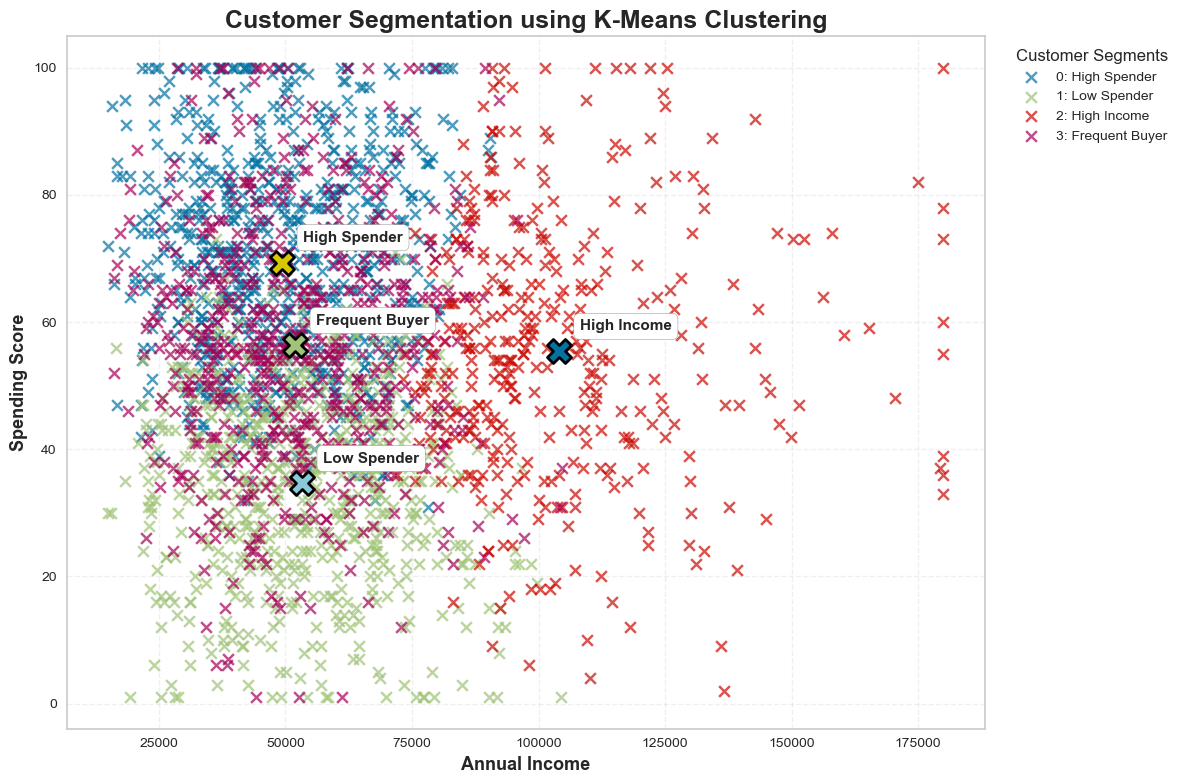

In [40]:
import matplotlib.pyplot as plt

# Cluster names based on your cluster analysis
cluster_names = {
    0: "High Spender",
    1: "Low Spender",
    2: "High Income",
    3: "Frequent Buyer"
}

# Create figure
plt.figure(figsize=(12, 8))

# Plot each cluster
for cluster in sorted(df["clusters"].unique()):

    cluster_data = df[df["clusters"] == cluster]

    plt.scatter(
        cluster_data["AnnualIncome"],
        cluster_data["SpendingScore"],
        marker="x",
        s=60,
        alpha=0.7,
        label=f"{cluster}: {cluster_names[cluster]}"
    )

# Calculate cluster centers
centers = df.groupby("clusters")[[
    "AnnualIncome",
    "SpendingScore"
]].mean()

# Plot cluster centers
for cluster in centers.index:

    x = centers.loc[cluster, "AnnualIncome"]
    y = centers.loc[cluster, "SpendingScore"]

    plt.scatter(
        x,
        y,
        marker="X",
        s=300,
        edgecolor="black",
        linewidth=2,
        zorder=5
    )

    # Add cluster name
    plt.annotate(
        cluster_names[cluster],
        (x, y),
        xytext=(15, 15),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="gray"
        )
    )

# Title
plt.title(
    "Customer Segmentation using K-Means Clustering",
    fontsize=18,
    fontweight="bold"
)

# Labels
plt.xlabel(
    "Annual Income",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Spending Score",
    fontsize=13,
    fontweight="bold"
)

# Grid
plt.grid(
    linestyle="--",
    alpha=0.3
)

# Legend
plt.legend(
    title="Customer Segments",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Conclusion :  

The Customer Segmentation project successfully applied **K-Means Clustering** to identify distinct customer groups based on **age, annual income, spending score, and purchase frequency**.   

The **Elbow Method and Distortion Score** were used to determine an appropriate number of clusters, while the **Silhouette Score** was used to evaluate the quality of the clustering. **PCA visualization** provided a clear two-dimensional representation of the identified customer segments.   

The resulting clusters reveal differences in customer characteristics and purchasing behavior, enabling businesses to better understand their customer base and develop **targeted marketing strategies, personalized offers, customer retention programs, and more effective business decisions**.   

Overall, this project demonstrates how **unsupervised machine learning can transform raw customer data into meaningful and actionable business insights**.   


## Practical Business Actions : 

Based on the identified customer segments, businesses can take the following actions:   

* **High-Spending & High-Frequency Customers:** Reward with loyalty programs, exclusive offers, and premium benefits to increase retention.   
* **High-Income but Low-Spending Customers:** Use personalized promotions, product recommendations, and targeted campaigns to increase engagement.     
* **Moderate-Spending Regular Customers:** Encourage repeat purchases through memberships, bundles, and loyalty rewards.     
* **Low-Spending & Low-Frequency Customers:** Use re-engagement campaigns, discounts, and personalized offers to improve customer activity.      
* **High-Potential Customers:** Identify customers showing strong purchase frequency or spending potential and provide targeted incentives to move them into higher-value segments.   

These segmentation insights can help businesses **allocate marketing budgets more effectively, personalize customer experiences, improve retention, and increase customer lifetime value**.   
